<a href="https://colab.research.google.com/github/njones61/xslope/blob/main/docs/seepage/xslope_seep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# XSLOPE - Seepage Analysis

This notebook illustrates how to use xslope to solve a seepage problem using a 2D finite element solution.

## Install xslope and import functions

In [1]:
# Install the xslope package
# - Basic install (limit equilibrium only): pip install xslope
# - Full install (with FEM features): pip install xslope[fem]

%%capture
!apt-get update && apt-get install -y libgl1-mesa-glx libglu1-mesa # required by gmsh
!pip install xslope[fem]==0.1.5
!pip install gmsh

In [2]:
# Import functions

import xslope as xslope

from xslope.fileio import load_slope_data, print_dictionary
from xslope.mesh import build_polygons, build_mesh_from_polygons, export_mesh_to_json, import_mesh_from_json
from xslope.plot import plot_inputs, plot_mesh, plot_polygons, plot_polygons_separately
from xslope.plot_seep import plot_seep_data, plot_seep_solution
from xslope.seep import build_seep_data, run_seepage_analysis, save_seep_data_to_json, export_seep_solution

## Upload Excel template

In [3]:
# Upload excel input template for selected problem

from google.colab import files
upload = files.upload()
file_name = list(upload.keys())[0]

Saving input_template_clay_blanket.xlsx to input_template_clay_blanket.xlsx


## Load slope data

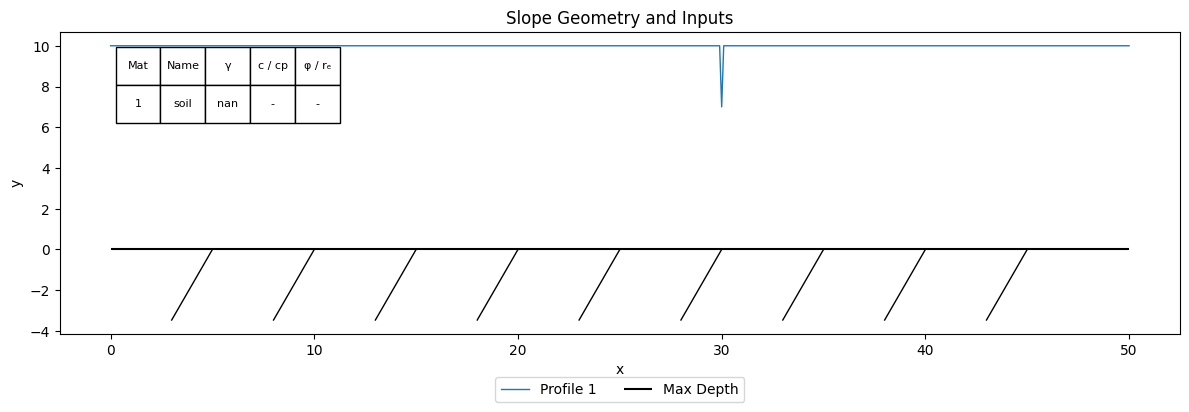

In [4]:
slope_data = load_slope_data(file_name)

plot_inputs(slope_data)


In [5]:
# @title Select element type {"run":"auto"}
elem_type = "tri3" # @param ["tri3","tri6","quad4","quad8","quad9"]
elem_size = .75 # @param {"type":"number"}

## Build mesh

Mesh tolerance for boundary conditions: 0.031466


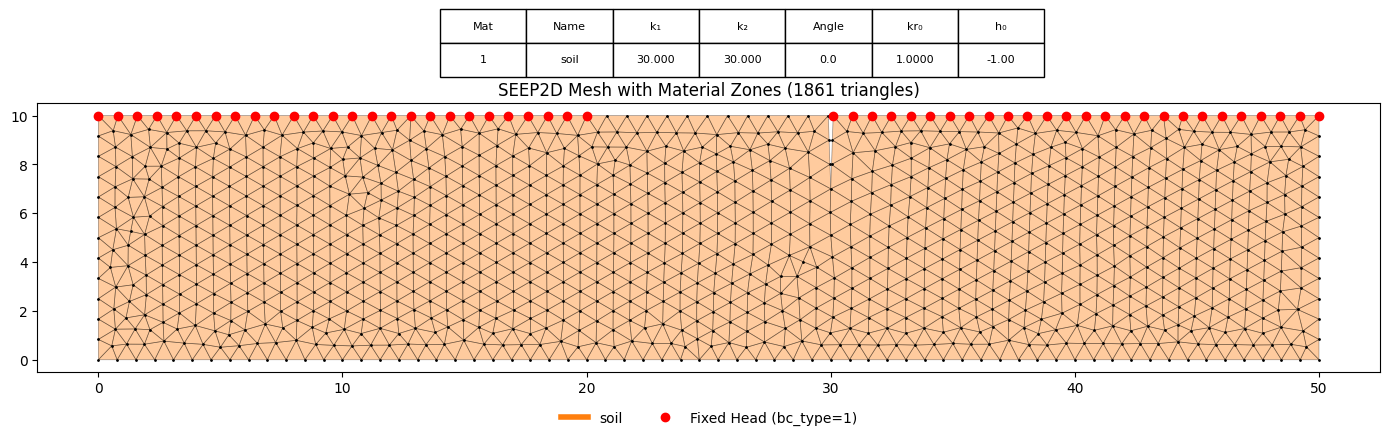

In [6]:
polygons = build_polygons(slope_data)

mesh = build_mesh_from_polygons(polygons, elem_size, elem_type)

seep_data = build_seep_data(mesh, slope_data)

plot_seep_data(seep_data, show_nodes=True, show_bc=True, material_table=True, label_elements=False, label_nodes=False)

## Run seepage analysis

Solving CONFINED seepage problem...
Number of fixed-head nodes: 52
Number of exit face nodes: 0
phi min: 28.807, max: 69.475
Plotting 1861 linear triangles, 0 quadratic triangles, 0 linear quads, 0 8-node quads, 0 9-node quads
Computed nf: 13.10, using 14 φ contours (flowrate=40.669, base k=30.0, head drop=3.000)


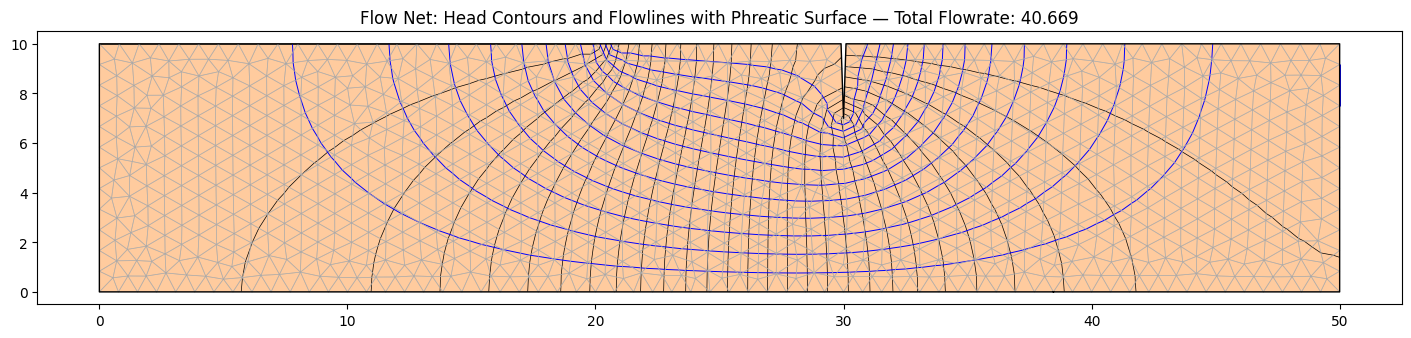

In [7]:
solution = run_seepage_analysis(seep_data)

plot_seep_solution(seep_data, solution, levels=30, base_mat=1, fill_contours=False, phreatic=True)